In [13]:
import pandas as pd
import numpy as np

Data loading and data parsing

In [14]:
df = pd.read_csv("Data/kenya.csv")

In [15]:
#Adding a Country column
df["Country"] = "kenya"

In [16]:
#Convering YEAR and DOY into a proper datetime column
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [17]:
#Extract Month as a separate column for seasonal analysis
df["month"] = df["date"].dt.month

In [18]:
#checking if the changes re actually made
df[["YEAR", "DOY", "date", "month", "Country"]].head()

,YEAR,DOY,date,month,Country
0,2015,1,2015-01-01,1,kenya
1,2015,2,2015-01-02,1,kenya
2,2015,3,2015-01-03,1,kenya
3,2015,4,2015-01-04,1,kenya
4,2015,5,2015-01-05,1,kenya


Summary Statistics & Missing-Value Report

In [19]:
#Replace -999 with NaN (Do this first!)
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,kenya,2026-03-30,3


In [20]:
#Checking for duplicates
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 0


In [21]:
###Drop duplicates if any exist
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

In [22]:
#descriptive statistics for all numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


This section gives as the average,minumum,maximum,std,and interquatile values... of each column giving as a general understandng of the data.   For instance the mean daily air temperature at 2 meters above the surface is 20.42 degrees as observed in the output.

In [23]:
#Compute null counts and percentages
null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100

# Create a summary table
missing_report = pd.DataFrame({
    'Null Count': null_counts,
    'Percentage (%)': null_percentages
    })

In [24]:
# Display only columns with missing data
print("Missing Data Report:")
print(missing_report[missing_report['Null Count'] > 0])

Missing Data Report:
Empty DataFrame
Columns: [Null Count, Percentage (%)]
Index: []


In [25]:
# List columns with > 5% nulls
high_nulls = null_percentages[null_percentages > 5]
if not high_nulls.empty:
    print("\nColumns with > 5% Missing Data:")
    for col, val in high_nulls.items():
        print(f"- {col}: {val:.2f}%")
else:
    print("\nNo columns exceed 5% missing data.")


No columns exceed 5% missing data.


Since no columns exceed the 5% null threshold, we can proceed with full confidence in our statistial analysis work.

Outlier Detection & Basic Cleaning

In [26]:
#Outlier Detection & Basic Cleaning
from scipy import stats

# Columns to check for outliers
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate absolute Z-scores
z_scores = np.abs(stats.zscore(df[weather_cols]))

# Create a boolean mask where any column has |Z| > 3
outlier_mask = (z_scores > 3).any(axis=1)
outlier_count = outlier_mask.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {outlier_count}")

Total rows flagged as outliers (|Z| > 3): 121


It would be better to keep the outliers since these extreme values tells us a sudden spike in the weather condition and is no an error made by measurement.And this extreme weather conditions are naturally expected.

In [27]:
#List of all weather-related variables to be filled
weather_variables = [
    'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 
    'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 
    'PS', 'QV2M'
]

In [28]:
#Drop rows with >30% missing values
# (If a row has less than 70% of the columns filled, we discard it as unreliable)
initial_rows = len(df)
df.dropna(thresh=int(len(df.columns) * 0.7), inplace=True)
dropped_rows = initial_rows - len(df)

#  Apply forward-fill to the specific weather columns
# This propagates the last valid observation forward to next valid
df[weather_variables] = df[weather_variables].ffill()

print(f"Cleaning complete.")
print(f"Rows dropped (threshold < 70%): {dropped_rows}")

Cleaning complete.
Rows dropped (threshold < 70%): 0


In [29]:
df.to_csv('Data/kenya_clean.csv', index=False)
print("Data saved to Data/kenya_clean.csv")

Data saved to Data/kenya_clean.csv


Time Series Analysis


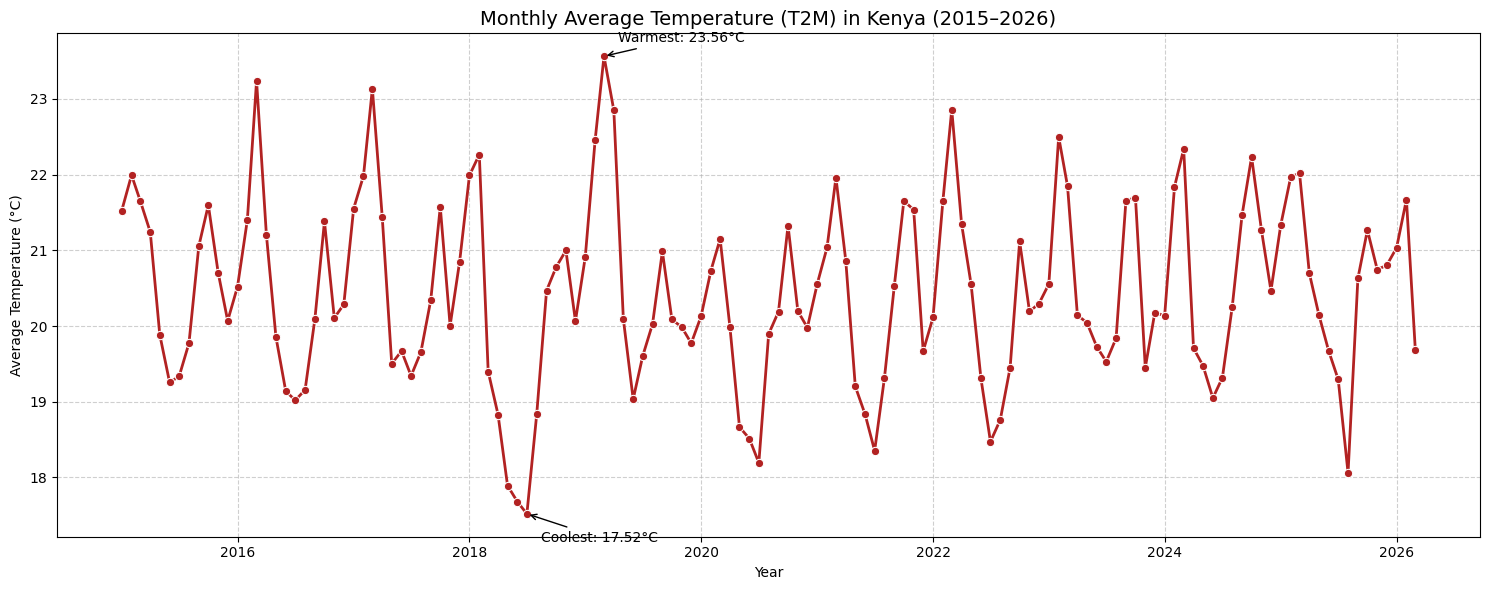

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate data to monthly level
monthly_df = df.groupby(['YEAR', 'month']).agg({
    'T2M': 'mean', 
    'PRECTOTCORR': 'sum'
}).reset_index()

# 2. CREATE A TRUE DATETIME COLUMN (This fixes the error)
monthly_df['Plot_Date'] = pd.to_datetime(monthly_df[['YEAR', 'month']].assign(day=1))

# Find coordinates for annotations using the new Plot_Date
warmest = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest = monthly_df.loc[monthly_df['T2M'].idxmin()]

# 3. Plotting with true dates
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_df, x='Plot_Date', y='T2M', marker='o', color='firebrick', linewidth=2)

# Annotations use the Plot_Date
plt.annotate(f"Warmest: {warmest['T2M']:.2f}°C", 
             xy=(warmest['Plot_Date'], warmest['T2M']), xytext=(10, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.annotate(f"Coolest: {coolest['T2M']:.2f}°C", 
             xy=(coolest['Plot_Date'], coolest['T2M']), xytext=(10, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title("Monthly Average Temperature (T2M) in Kenya (2015–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

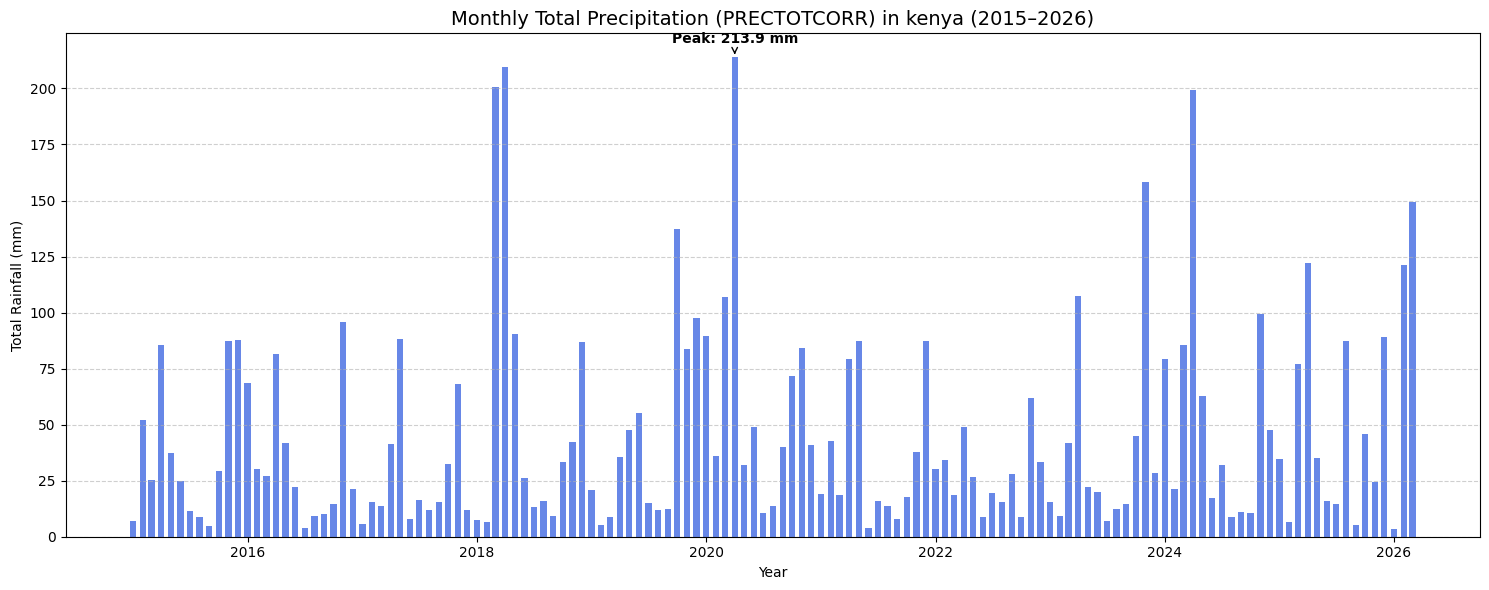

In [31]:
# Find the peak rainy month
peak_rain = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmax()]

# Plotting using Plot_Date
plt.figure(figsize=(15, 6))
# Using a fixed width to make bars look nice with dates (approx 20 days wide)
plt.bar(monthly_df['Plot_Date'], monthly_df['PRECTOTCORR'], color='royalblue', alpha=0.8, width=20)

plt.annotate(f"Peak: {peak_rain['PRECTOTCORR']:.1f} mm", 
             xy=(peak_rain['Plot_Date'], peak_rain['PRECTOTCORR']), xytext=(0, 10),
             textcoords='offset points', ha='center', fontweight='bold',
             arrowprops=dict(arrowstyle='->'))

plt.title("Monthly Total Precipitation (PRECTOTCORR) in kenya (2015–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In the test series analysis,the warmest average monthly tempreture recorded is 23.56 degrees while the coolest that is recorded is 17.52. In the monthly precipitation; the highest peak rain is 213.9mm.

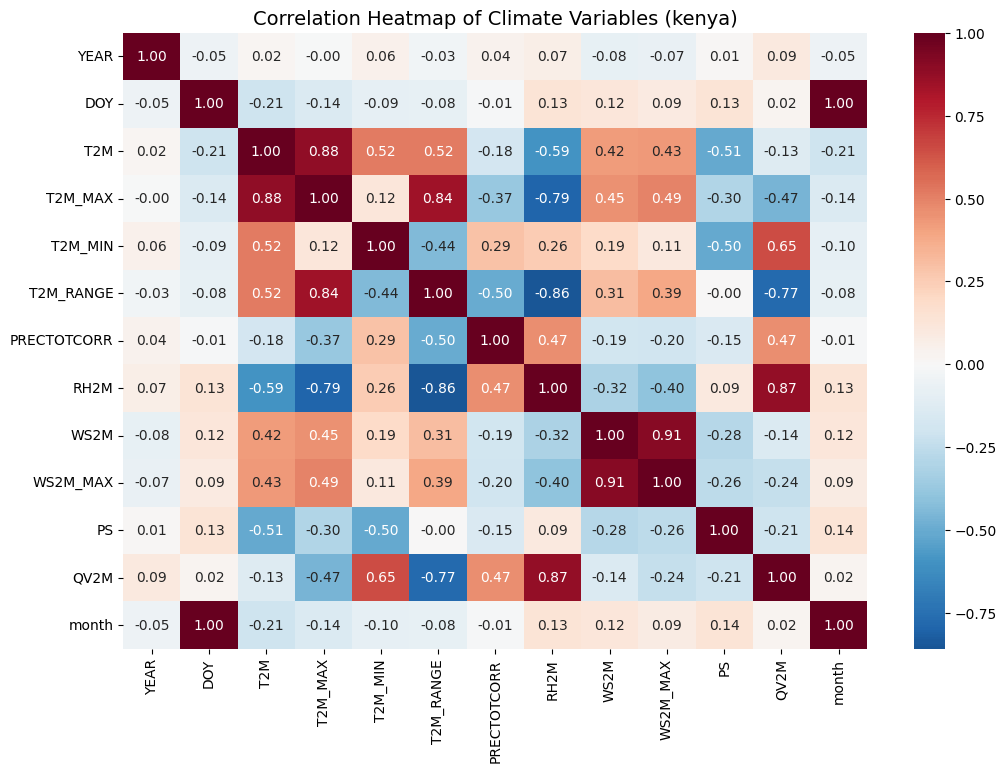

In [32]:
#correltion 
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_cols.corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f", center=0)

plt.title("Correlation Heatmap of Climate Variables (kenya)", fontsize=14)
plt.show()

The 3 strongest correlations observed
    1.T2M and T2M_MAX (Positive Correlation: 0.88)
This high correlation indicates that the daily mean temperature is almost entirely driven by the daytime/high temperatures.

    2.RH2M and QV2M(positive Correlation: 0.87)
This shows that Relative humidity at 2 meters and Specific humidity - mass of water vapor per unit mass of moist air are strongly related were one affects the other positively.
    
    3.WS2M and WS2M_MAX(positive correlation:0.91)

This shows that Mean daily wind speed at 2 meters and Maximum daily wind speed at 2 meters have high correlation. This shows that the maximum wind speed will affect the mean i.e when max wind speed is high the mean will also be high. And this is expected based on basic maths concept for calculating mean.

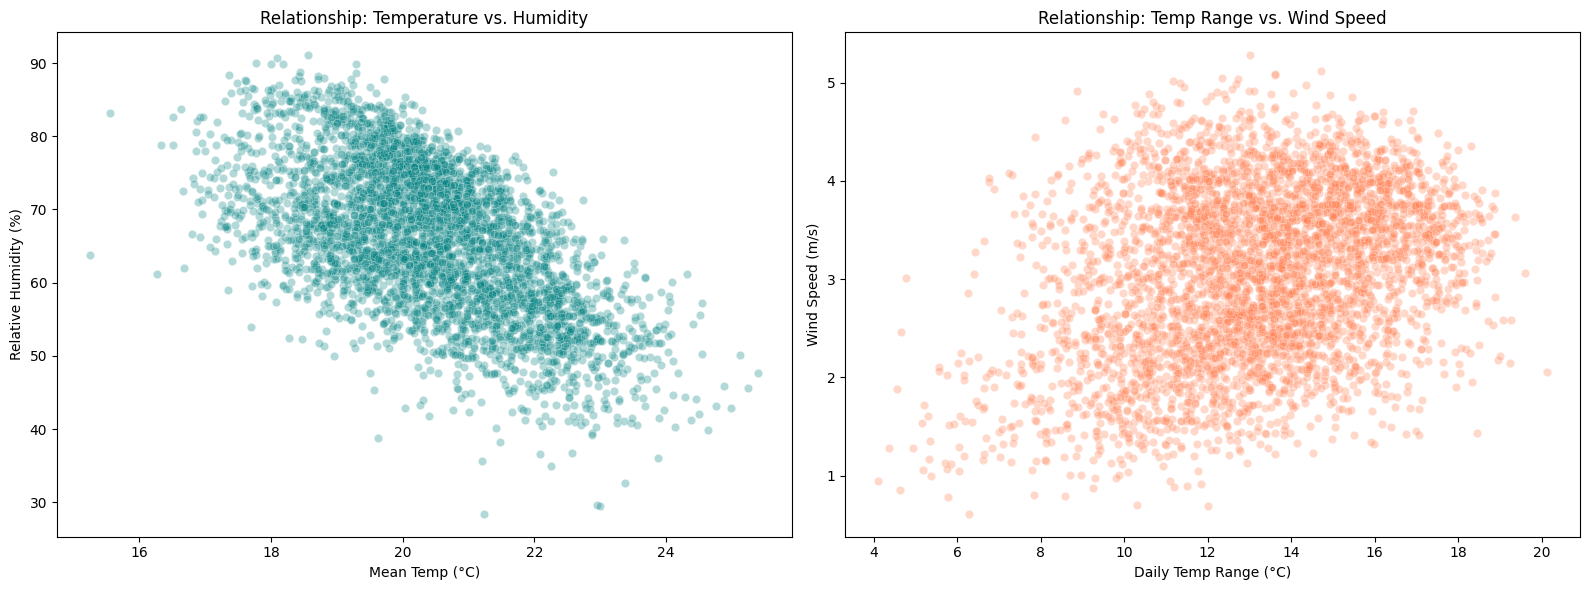

In [33]:
#sactter plots
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, color='teal', ax=ax1)
ax1.set_title("Relationship: Temperature vs. Humidity")
ax1.set_xlabel("Mean Temp (°C)")
ax1.set_ylabel("Relative Humidity (%)")

# Plot 2: Temp Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, color='coral', ax=ax2)
ax2.set_title("Relationship: Temp Range vs. Wind Speed")
ax2.set_xlabel("Daily Temp Range (°C)")
ax2.set_ylabel("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

Distribution Analysis

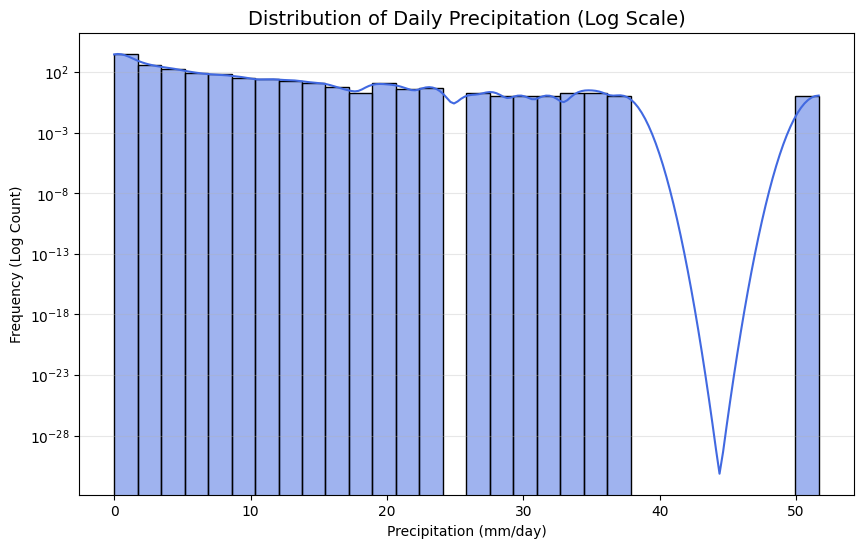

In [34]:
plt.figure(figsize=(10, 6))

# Histogram with Log Scale on the Y-axis to handle skewness
sns.histplot(df['PRECTOTCORR'], bins=30, color='royalblue', kde=True)
plt.yscale('log')  # Apply log scale

plt.title("Distribution of Daily Precipitation (Log Scale)", fontsize=14)
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Log Count)")
plt.grid(axis='y', alpha=0.3)
plt.show()

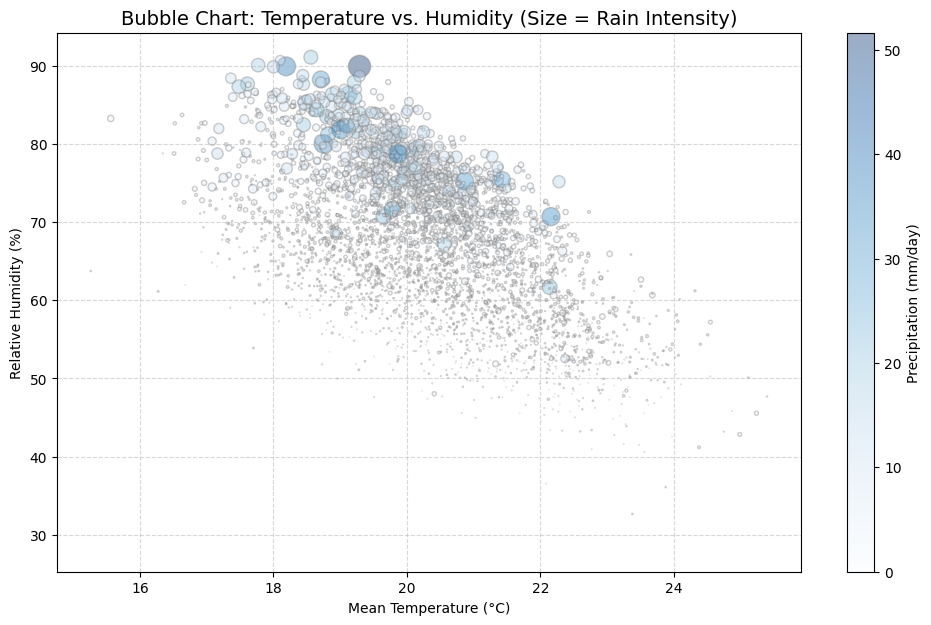

In [35]:
plt.figure(figsize=(12, 7))

# We use a subset or alpha to prevent the chart from being too crowded
# Size is scaled by PRECTOTCORR (multiplied by 5 to make bubbles visible)
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR'] * 5, 
                      c=df['PRECTOTCORR'], 
                      cmap='Blues', alpha=0.4, edgecolors='grey')

# Add a colorbar to show rain intensity
plt.colorbar(scatter, label='Precipitation (mm/day)')

plt.title("Bubble Chart: Temperature vs. Humidity (Size = Rain Intensity)", fontsize=14)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()